In [1]:
## standard imports
import numpy as np
import scipy
import matplotlib.pyplot as plt
from copy import deepcopy
from tqdm import tqdm

In [2]:
from scipy.stats import uniform, norm, gaussian_kde, beta, binom, Mixture
from scipy.special import gamma, logsumexp

In [3]:
!pip install dynesty

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.9/102.9 kB 4.3 MB/s eta 0:00:00


In [4]:
from dynesty import NestedSampler

In [5]:
!pip install corner

In [6]:
import corner

# Beta distribution

In [20]:
p_true = 0.5
n = 10
likelihood = binom(p=p_true,n=n)
k = likelihood.rvs()
print(k)

6


In [21]:
def ptform(u):
  xmin = 0.0
  xmax = 1.0
  x = uniform.ppf(u,loc=xmin,scale=xmax-xmin)
  return x

def loglike(x):
  out = binom.logpmf(k=k,n=n,p=x)[0]
  return out

In [22]:
ndim = 1
nlive = 1000
sampler = NestedSampler(loglike, ptform, ndim, nlive=nlive)
sampler.run_nested()
res = sampler.results
samples = res.samples_equal()

1433it [00:01, 759.64it/s, +1000 | bound: 0 | nc: 1 | ncall: 5116 | eff(%): 59.111 | loglstar:   -inf < -1.383 <    inf | logz: -2.423 +/-    nan | dlogz:  0.001 >  1.009]


In [23]:
dist = beta(a=k+1,b=n-k+1)
samples2 = dist.rvs(len(samples))

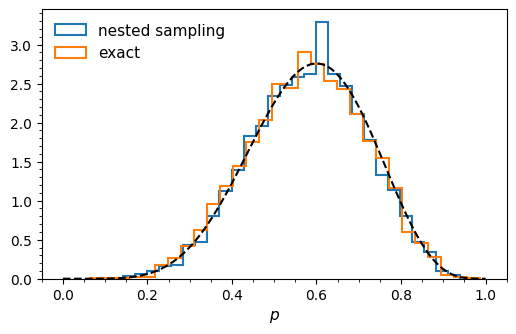

In [24]:
plt.figure(figsize=(6,3.5))

plt.hist(samples,bins=30,histtype='step',density=True,linewidth=1.5,label='nested sampling')
plt.hist(samples2,bins=30,histtype='step',density=True,linewidth=1.5,label='exact')

x = np.linspace(0,1,100)
y = dist.pdf(x)
plt.plot(x,y,color='k',linestyle='--')

plt.xlabel(r'$p$',fontsize=11)

plt.minorticks_on()

plt.legend(fontsize=11,frameon=False)

plt.show()

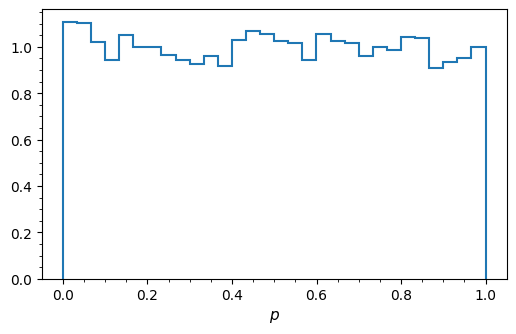

In [25]:
## note that beta(1,1)=uniform(0,1)
dist = beta(a=1,b=1)
samples3 = dist.rvs(10_000)

plt.figure(figsize=(6,3.5))

plt.hist(samples3,bins=30,histtype='step',density=True,linewidth=1.5)

plt.xlabel(r'$p$',fontsize=11)

plt.minorticks_on()

plt.show()

# Hierarchical inference (with closed-form likelihoods)

In [54]:
M = 100
n_true = np.random.randint(25,100,M)

# uniform in 0 1
#a_true = 1.0
#b_true = 1.0
#p_true = np.random.uniform(0,1,M)

# from a beta dist
#a_true = 1.5
#b_true = 2.5
#p_true = beta.rvs(a=a_true,b=b_true,size=M)

# constant
p_true = 0.3*np.ones((M))

In [55]:
k_true = np.zeros_like(p_true)
for i in range(M):
  k_true[i] = binom.rvs(p=p_true[i],n=n_true[i])

In [56]:
def ptform(u):
  xmin = np.array([0.1,0.1])
  xmax = np.array([10.0,10.0])
  out = uniform.ppf(u,loc=xmin,scale=xmax-xmin)
  return out

def loglike(x):
  ## convenient parametrization
  a,b = x
  out = 0.0
  for i in range(M):
    ni = n_true[i]
    ki = k_true[i]
    out += np.log(gamma(a+b)*gamma(a+ki)*gamma(ni-ki+b)/gamma(a+b+ni)/gamma(a)/gamma(b))
  return out

In [57]:
ndim = 2
nlive = 1000
sampler = NestedSampler(loglike, ptform, ndim, nlive=nlive)
sampler.run_nested()
res = sampler.results
samples = res.samples_equal()

6361it [01:07, 93.97it/s, +1000 | bound: 6 | nc: 1 | ncall: 43036 | eff(%): 17.511 | loglstar:   -inf < -3797.945 <    inf | logz: -3804.196 +/-  0.081 | dlogz:  0.001 >  1.009]


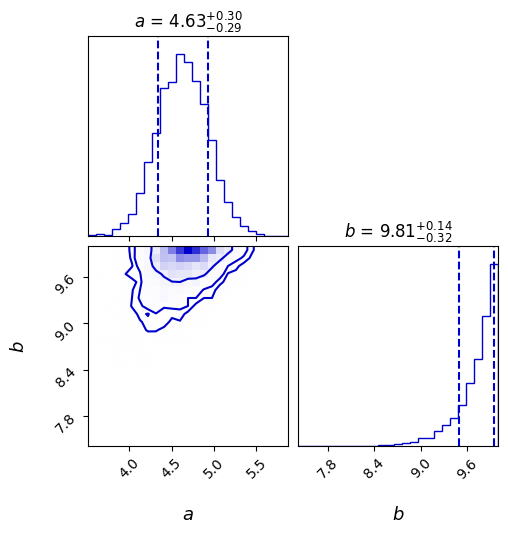

In [58]:
## corner plot of the posterior
## https://matplotlib.org/stable/gallery/color/named_colors.html

labels = [r'$a$',r'$b$']
truths = [a_true,b_true]

hist2d_kwargs = {'plot_datapoints':False,'fill_contours':False,
                 'levels':[0.68,0.90,0.95]}

fig = corner.corner(samples,bins=25,color='mediumblue',\
                    truths=truths,truth_color='firebrick',\
                    labels=labels,label_kwargs={'fontsize':13},\
                    quantiles = [0.16,0.84],\
                    show_titles=True,title_quantiles=[0.16,0.5,0.84],\
                    hist_kwargs={'density':True},\
                    **hist2d_kwargs,\
                    )

plt.show()

# Hierarchical inference (with sampled likelihoods)

In [59]:
## sample the likelihoods

n_samples = 1_00

data = []

for i in range(M):
  ki = k_true[i]
  ni = n_true[i]
  dist = beta(a=ki+1,b=ni-ki+1)
  data.append(dist.rvs(size=n_samples))

data = np.array(data)

In [60]:
def ptform(u):
  xmin = np.array([0.1,0.1])
  xmax = np.array([10.0,10.0])
  out = uniform.ppf(u,loc=xmin,scale=xmax-xmin)
  return out

def loglike(x):
  a,b = x
  log_p_pop = beta(a=a,b=b).logpdf(data)
  out = np.sum(logsumexp(log_p_pop,b=1/n_samples,axis=1))
  return out

In [61]:
ndim = 2
nlive = 1000
sampler = NestedSampler(loglike, ptform, ndim, nlive=nlive)
sampler.run_nested()
res2 = sampler.results
samples2 = res2.samples_equal()

6342it [03:00, 35.07it/s, +1000 | bound: 6 | nc: 1 | ncall: 42756 | eff(%): 17.583 | loglstar:   -inf < 100.468 <    inf | logz: 94.240 +/-  0.081 | dlogz:  0.001 >  1.009]


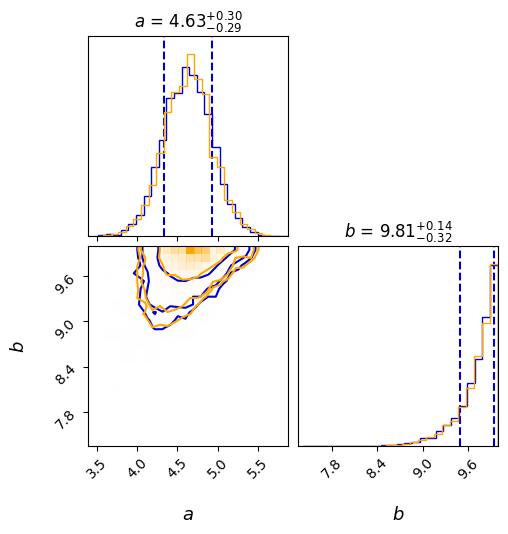

In [62]:
## corner plot of the posterior
## https://matplotlib.org/stable/gallery/color/named_colors.html

labels = [r'$a$',r'$b$']
truths = [a_true,b_true]

hist2d_kwargs = {'plot_datapoints':False,'fill_contours':False,
                 'levels':[0.68,0.90,0.95]}

fig = corner.corner(samples,bins=25,color='mediumblue',\
                    truths=truths,truth_color='firebrick',\
                    labels=labels,label_kwargs={'fontsize':13},\
                    quantiles = [0.16,0.84],\
                    show_titles=True,title_quantiles=[0.16,0.5,0.84],\
                    hist_kwargs={'density':True},\
                    **hist2d_kwargs,\
                    )

corner.corner(samples2,fig=fig,bins=25,color='orange',\
                    #truths=truths,truth_color='firebrick',\
                    #labels=labels,label_kwargs={'fontsize':13},\
                    #quantiles = [0.16,0.84],\
                    #show_titles=True,title_quantiles=[0.16,0.5,0.84],\
                    hist_kwargs={'density':True},\
                    **hist2d_kwargs,\
                    )

plt.show()

# Hierarchical inference (with sampled likelihoods and normal p_pop)

In [64]:
## sample the likelihoods

n_samples = 100

data = []

for i in range(M):
  ki = k_true[i]
  ni = n_true[i]
  dist = beta(a=ki+1,b=ni-ki+1)
  data.append(dist.rvs(size=n_samples))

data = np.array(data)

In [65]:
def ptform(u):
  xmin = np.array([0.,0.1])
  xmax = np.array([1.0,10.0])
  out = uniform.ppf(u,loc=xmin,scale=xmax-xmin)
  return out

def loglike(x):
  loc, scale = x
  log_p_pop = norm(loc=loc,scale=scale).logpdf(data)
  out = np.sum(logsumexp(log_p_pop,b=1/n_samples,axis=1))
  return out

def loglike_approx(x):
  loc, scale = x
  mu_i = k_true/n_true
  var_i = mu_i*(1-mu_i)/n_true
  out = np.sum(norm.logpdf(x=mu_i,loc=loc,scale=(scale**2+var_i)**0.5))
  return out

In [66]:
ndim = 2
nlive = 1000
sampler = NestedSampler(loglike, ptform, ndim, nlive=nlive)
sampler.run_nested()
res2 = sampler.results
samples2 = res2.samples_equal()

12231it [02:46, 73.29it/s, +1000 | bound: 16 | nc: 1 | ncall: 51165 | eff(%): 26.375 | loglstar:   -inf < 112.194 <    inf | logz: 100.061 +/-  0.114 | dlogz:  0.001 >  1.009]


In [68]:
ndim = 2
nlive = 1000
sampler = NestedSampler(loglike_approx, ptform, ndim, nlive=nlive)
sampler.run_nested()
res3 = sampler.results
samples3 = res3.samples_equal()

12213it [00:54, 225.47it/s, +1000 | bound: 17 | nc: 1 | ncall: 52514 | eff(%): 25.649 | loglstar:   -inf < 110.807 <    inf | logz: 98.700 +/-  0.113 | dlogz:  0.001 >  1.009]


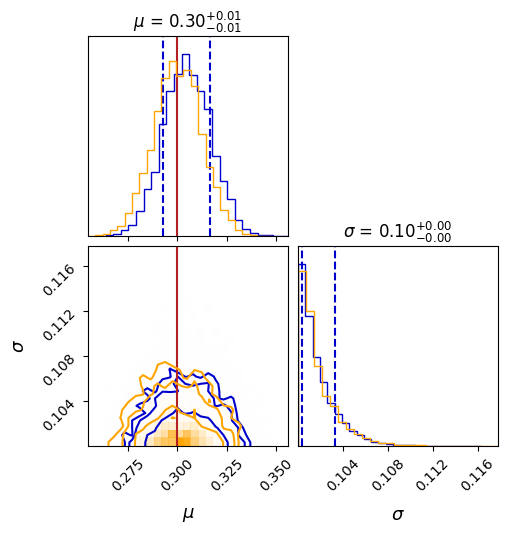

In [73]:
## corner plot of the posterior
## https://matplotlib.org/stable/gallery/color/named_colors.html

labels = [r'$\mu$',r'$\sigma$']
truths = [p_true[0], 0.0]

hist2d_kwargs = {'plot_datapoints':False,'fill_contours':False,
                 'levels':[0.68,0.90,0.95]}

fig = corner.corner(samples2,bins=25,color='mediumblue',\
                    truths=truths,truth_color='firebrick',\
                    labels=labels,label_kwargs={'fontsize':13},\
                    quantiles = [0.16,0.84],\
                    show_titles=True,title_quantiles=[0.16,0.5,0.84],\
                    hist_kwargs={'density':True},\
                    **hist2d_kwargs,\
                    )

corner.corner(samples3,fig=fig,bins=25,color='orange',\
                    #truths=truths,truth_color='firebrick',\
                    #labels=labels,label_kwargs={'fontsize':13},\
                    #quantiles = [0.16,0.84],\
                    #show_titles=True,title_quantiles=[0.16,0.5,0.84],\
                    hist_kwargs={'density':True},\
                    **hist2d_kwargs,\
                    )

plt.show()